Copyright © 2025 Giovanni Squillero / Politecnico di Torino  
https://github.com/squillero/programmer-zendo  
Free under certain conditions — see the license for details 

In [1]:
from itertools import accumulate
import numpy as np
from tqdm.auto import tqdm
from matplotlib import pyplot as plt

In [2]:
PROBLEM_SIZE = 5

In [3]:
def augmented(func):
    class _Augmnented:
        _log: list

        def __init__(self):
            self.clear()

        @property
        def log(self):
            return self._log[:]

        def clear(self):
            self._log = list()

        def plot(self, figsize=(14, 8)):
            best = list(accumulate(self._log, max))
            improvements = [(i, v) for i, v in list(enumerate(best)) if v > best[i - 1]]
            plt.figure(figsize=figsize)
            plt.scatter(range(len(self._log)), self._log, marker='.', color='lavender')
            plt.plot(range(len(best)), best, color='lightcoral')
            plt.scatter(
                [i for i, v in improvements],
                [v for i, v in improvements],
                marker='*',
                color='red',
            )

        def __call__(self, *args, **kwargs):
            self._log.append(func(*args, **kwargs))
            return self.log[-1]

    return _Augmnented()

In [4]:
@augmented
def fitness(sol):
    return -np.sum(np.square(sol))

In [5]:
def tweak(sol, stddev=0.1):
    return sol + np.random.normal(loc=0, scale=stddev, size=sol.size)

In [6]:
sol = np.random.rand(PROBLEM_SIZE) * 2 - 1
for _ in range(100):
    fitness(tweak(sol))

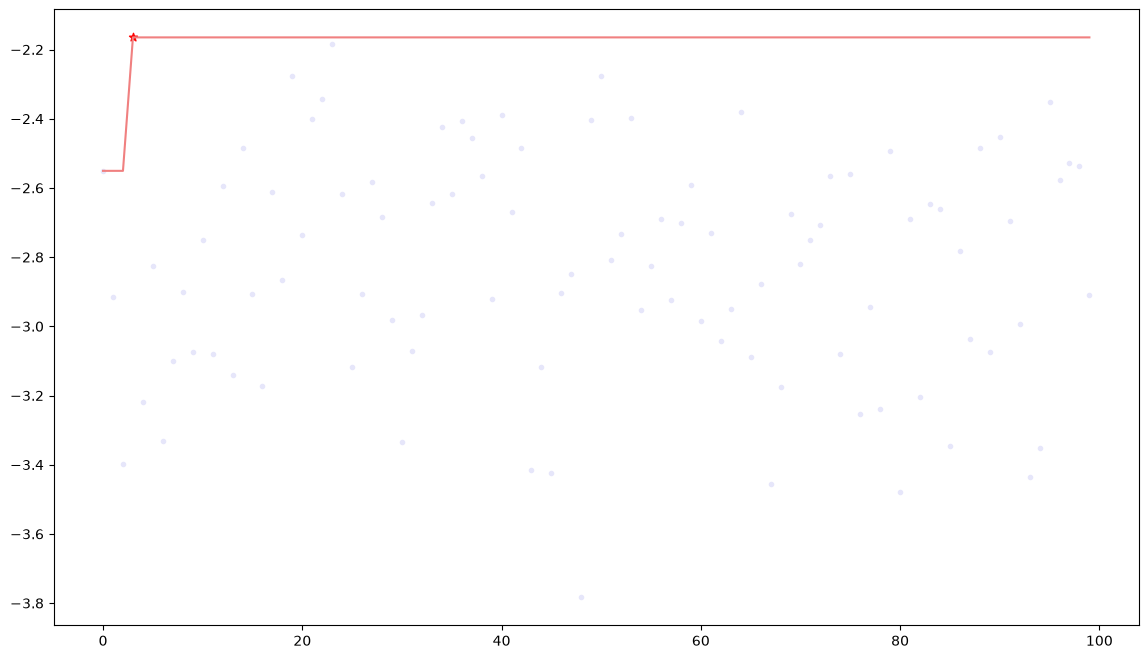

In [7]:
fitness.plot()